In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tessreduce as tr
%matplotlib notebook

In [2]:
flux = np.load('../../test_tessellate/sector38_cam4_ccd1_cut3_of64_ReducedFlux.npy')
ref = np.load('../../test_tessellate/sector38_cam4_ccd1_cut3_of64_Ref.npy')

<IPython.core.display.Javascript object>


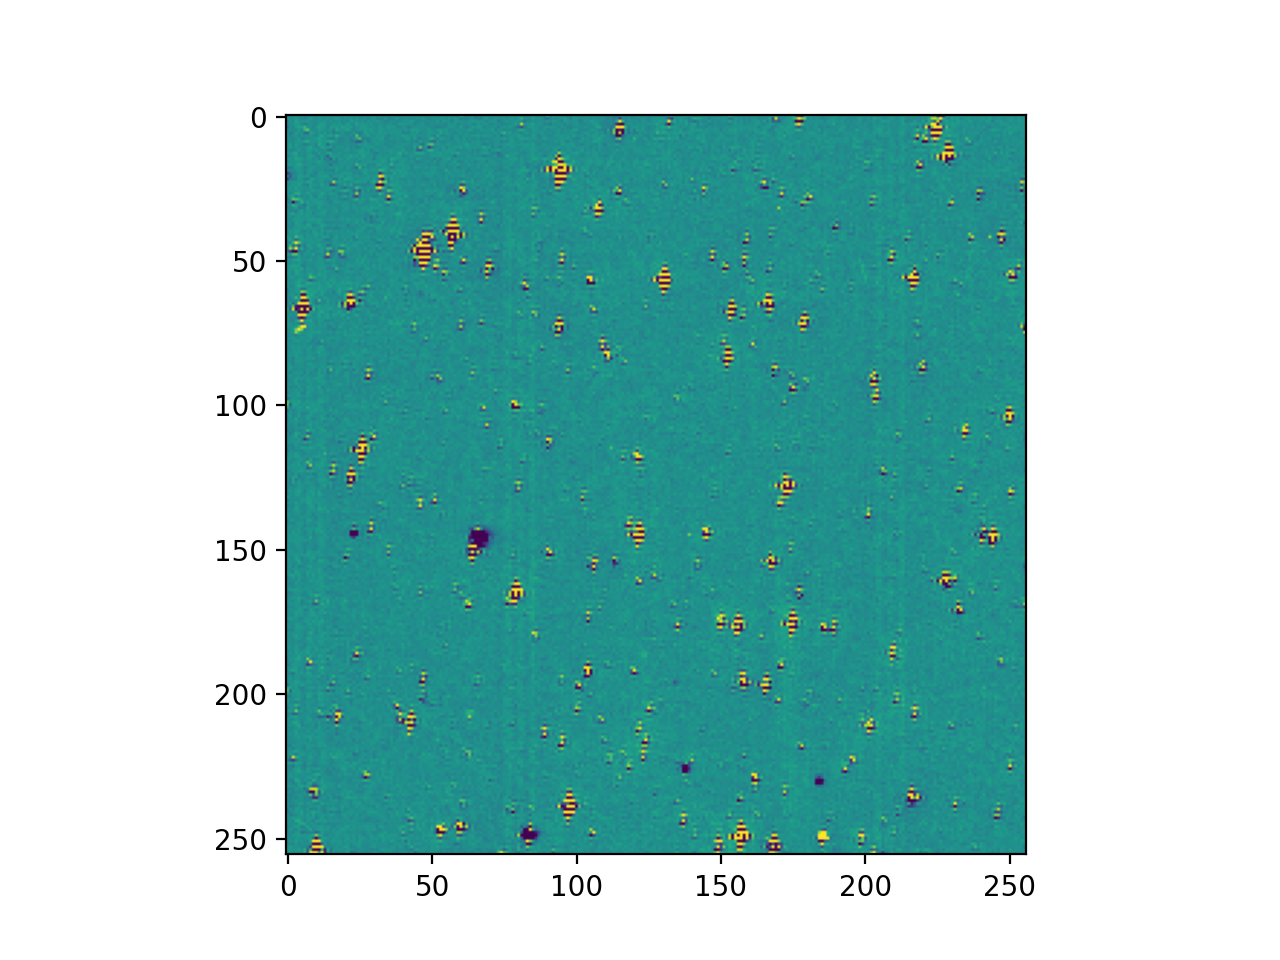

In [10]:
plt.figure()
plt.imshow(flux[2756],vmax=10,vmin=-10)

<IPython.core.display.Javascript object>


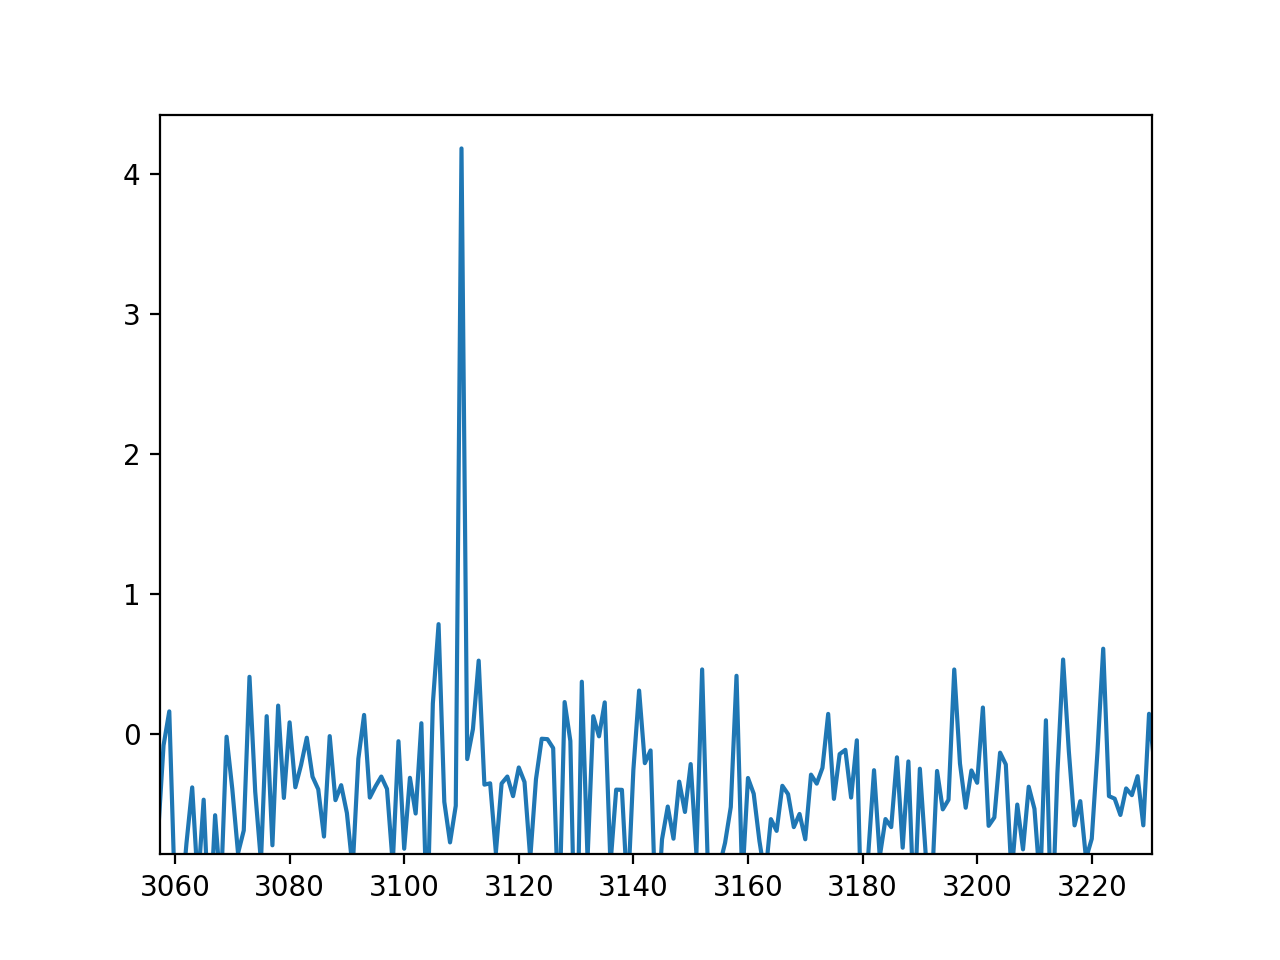

In [6]:
plt.figure()
plt.plot(flux[:,143,173])

made reference
made source mask
calculating background
adaptive bkg
background subtracted
aligning images
[SepAligner] 229 sources selected for alignment


<IPython.core.display.Javascript object>


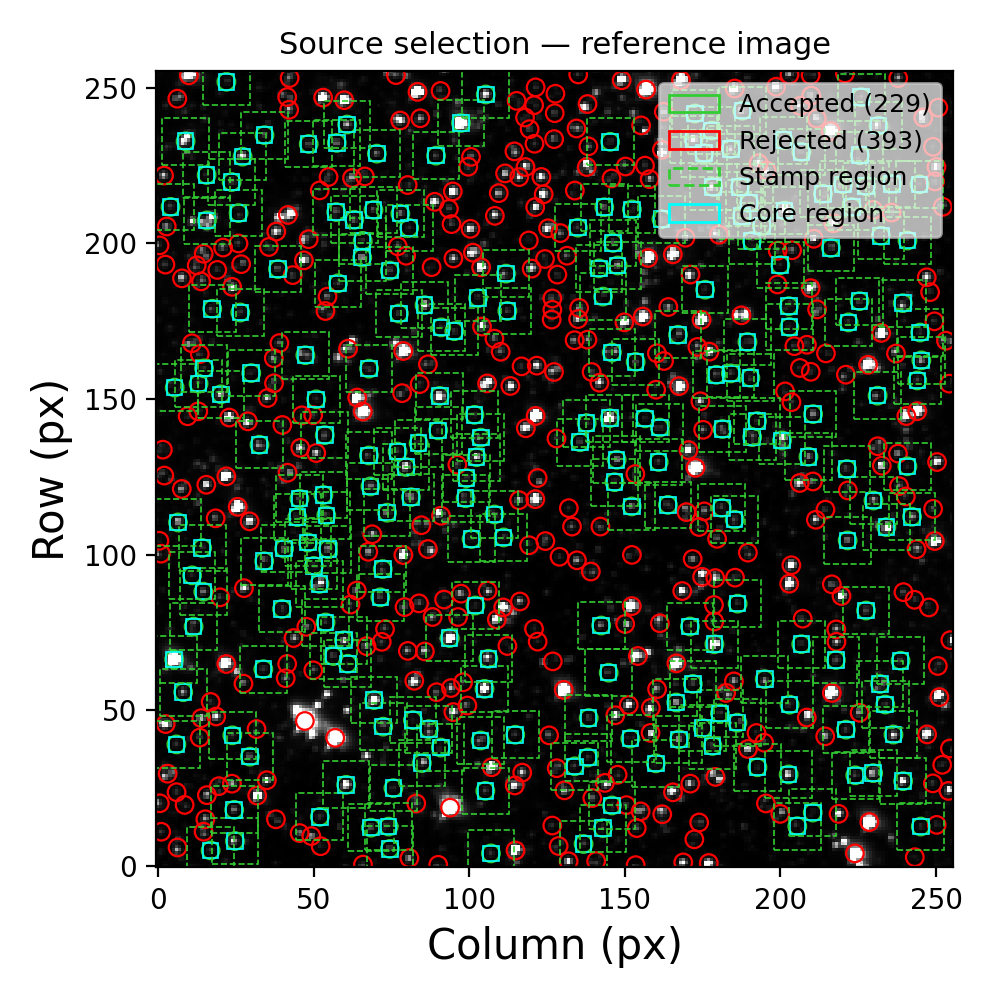

<IPython.core.display.Javascript object>


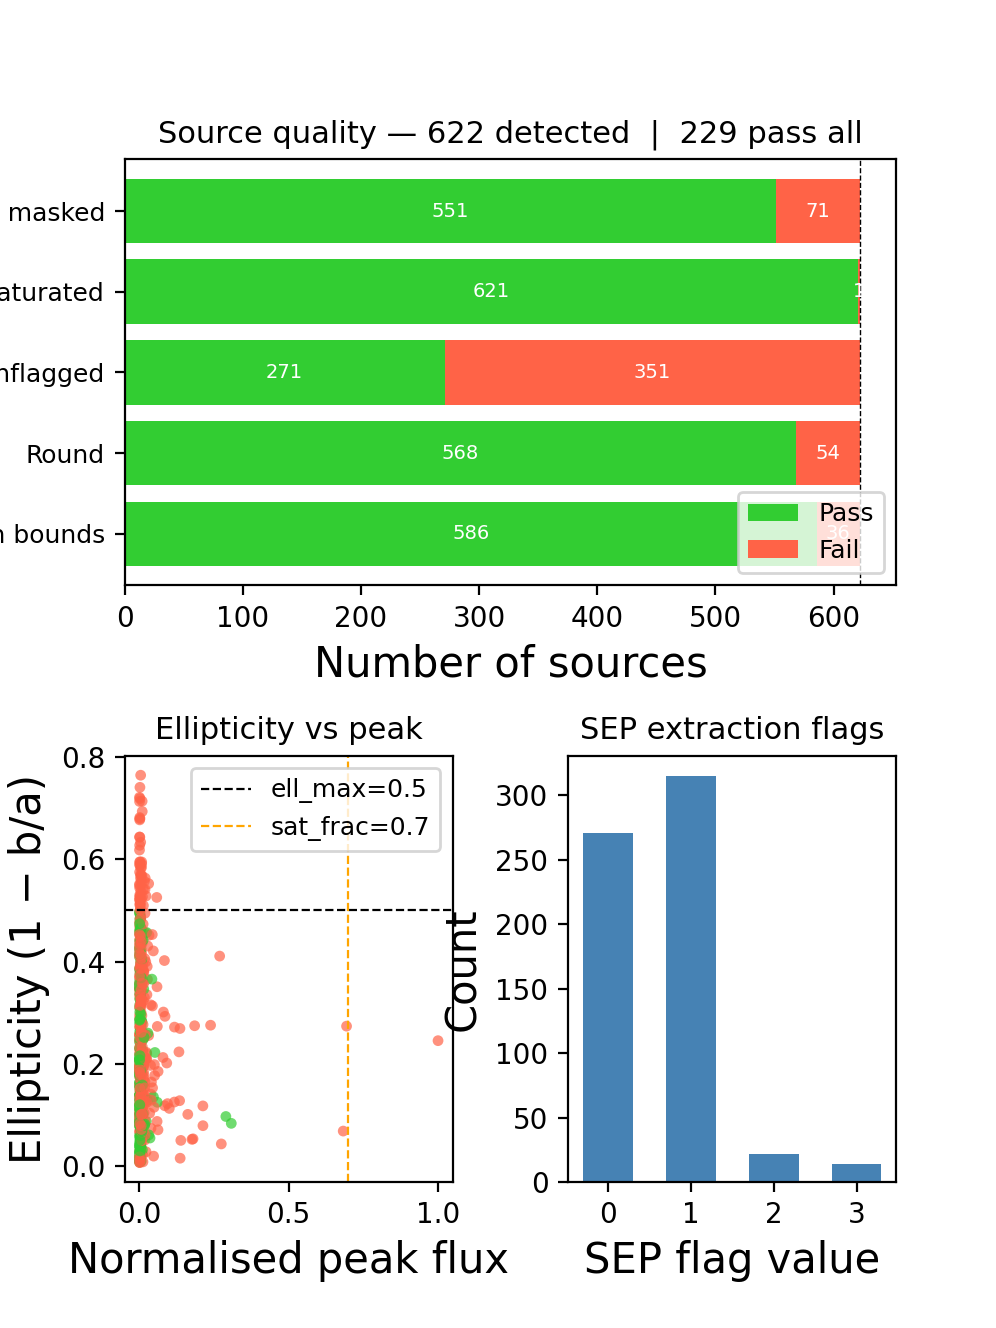

<IPython.core.display.Javascript object>


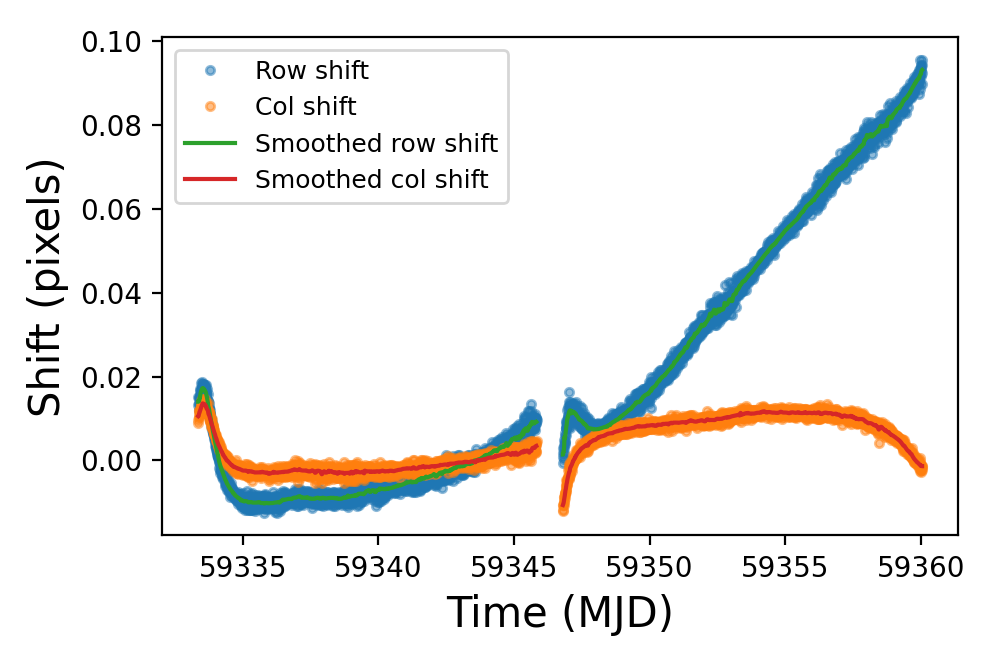

images shifted


<IPython.core.display.Javascript object>


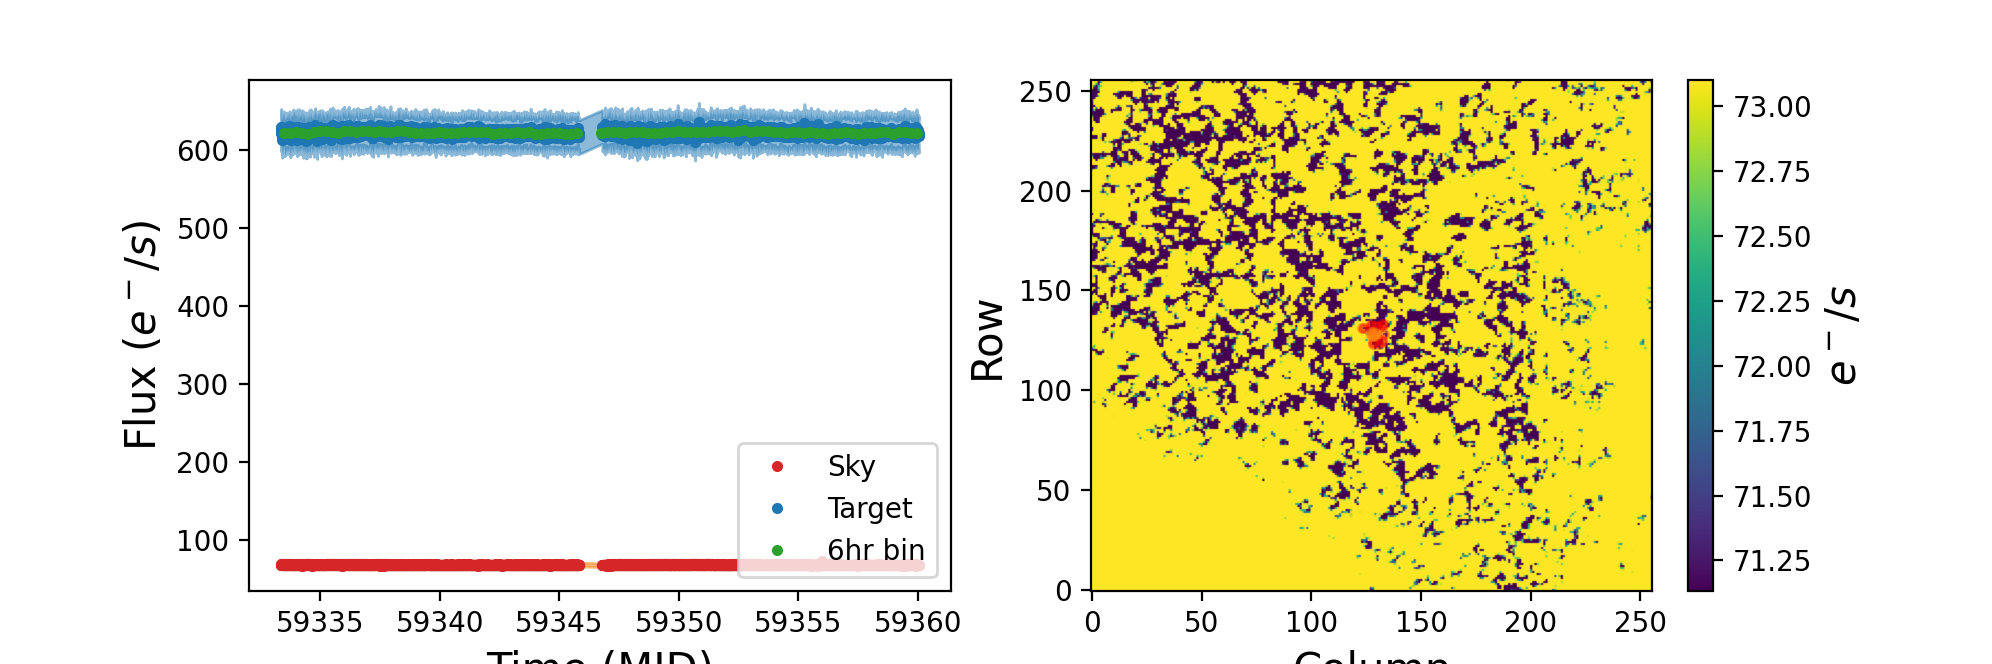

In [2]:
tess = tr.tessreduce(tpf='/Users/rri38/Documents/work/data/tess/tessellate_test/sector38_cam4_ccd1_cut3_of64_s38.fits',
                     calibrate=False,quality_bitmask='hard',reduce=True,diff=False,align=True,
                     shift_method='sep_core',diagnostic_plot=True)

<IPython.core.display.Javascript object>


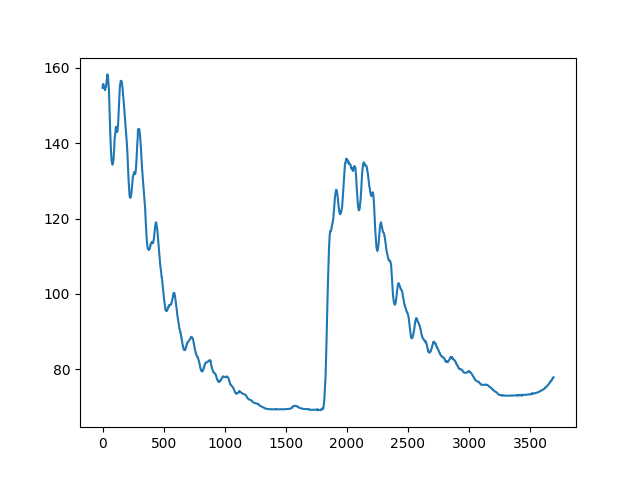

In [3]:
plt.figure()
plt.plot(tess.bkg[:,100,100])

In [7]:
tess.tpf.sector

In [6]:
tess.tpf.cameraera

4

In [4]:
import numpy as np
from scipy.ndimage import median_filter


def adaptive_medfilt_3d(
    data,
    w_min=3,
    w_max=51,
    grad_smooth_window=11,
    low_pct=5,
    high_pct=95,
    per_pixel_norm=True,
):
    data = np.asarray(data, dtype=float)
    T, X, Y = data.shape

    # NaN fill along time axis
    nan_mask = ~np.isfinite(data)
    data_filled = data.copy()
    if nan_mask.any():
        t_ax = np.arange(T, dtype=float)
        for xi in range(X):
            for yi in range(Y):
                ts = data[:, xi, yi]
                bad = ~np.isfinite(ts)
                if bad.all():
                    data_filled[:, xi, yi] = 0.0
                elif bad.any():
                    data_filled[:, xi, yi] = np.interp(t_ax, t_ax[~bad], ts[~bad])

    # Gradient → smooth → |grad|
    grad = np.gradient(data_filled, axis=0)
    gw = _make_odd(grad_smooth_window)
    abs_grad = np.abs(median_filter(grad, size=(gw, 1, 1), mode='reflect'))

    # Map |gradient| → window size
    if per_pixel_norm:
        g_lo = np.nanpercentile(abs_grad, low_pct, axis=0, keepdims=True)
        g_hi = np.nanpercentile(abs_grad, high_pct, axis=0, keepdims=True)
    else:
        g_lo = np.nanpercentile(abs_grad, low_pct)
        g_hi = np.nanpercentile(abs_grad, high_pct)

    dg = np.where((g_hi - g_lo) > 0, g_hi - g_lo, 1.0)
    norm = np.clip((abs_grad - g_lo) / dg, 0.0, 1.0)

    raw = w_max - norm * (w_max - w_min)
    windows = np.round(raw).astype(int)
    windows += (1 - windows % 2)
    windows = np.clip(windows, _make_odd(w_min), _make_odd(w_max))

    # Adaptive median: loop over unique window sizes
    result = np.empty((T, X, Y))
    for w in np.unique(windows):
        smoothed_w = median_filter(data_filled, size=(w, 1, 1), mode='reflect')
        result[windows == w] = smoothed_w[windows == w]

    result[nan_mask] = np.nan
    return result, windows, abs_grad


def _make_odd(x):
    x = max(int(x), 3)
    return x if x % 2 == 1 else x + 1

In [8]:
data = tr.deepcopy(tess.bkg)
w_min=3
w_max=51
grad_smooth_window=11
low_pct=5
high_pct=95
per_pixel_norm=True

data = np.asarray(data, dtype=float)
T, X, Y = data.shape

# NaN fill along time axis
nan_mask = ~np.isfinite(data)
data_filled = data.copy()
if nan_mask.any():
    t_ax = np.arange(T, dtype=float)
    for xi in range(X):
        for yi in range(Y):
            ts = data[:, xi, yi]
            bad = ~np.isfinite(ts)
            if bad.all():
                data_filled[:, xi, yi] = 0.0
            elif bad.any():
                data_filled[:, xi, yi] = np.interp(t_ax, t_ax[~bad], ts[~bad])

# Gradient → smooth → |grad|
grad = np.gradient(data_filled, axis=0)
gw = _make_odd(grad_smooth_window)
abs_grad = np.abs(median_filter(grad, size=(gw, 1, 1), mode='reflect'))

# Map |gradient| → window size
if per_pixel_norm:
    g_lo = np.nanpercentile(abs_grad, low_pct, axis=0, keepdims=True)
    g_hi = np.nanpercentile(abs_grad, high_pct, axis=0, keepdims=True)
else:
    g_lo = np.nanpercentile(abs_grad, low_pct)
    g_hi = np.nanpercentile(abs_grad, high_pct)



In [35]:
np.save('test_bkg.npy',tess.bkg)
np.save('test_bkg_time.npy',tess.mjd)

In [31]:
acc = np.gradient(median_filter(grad, size=(gw, 1, 1), mode='reflect'),axis=0)


In [32]:
sacc = median_filter(acc, size=(21, 1, 1), mode='reflect')

<IPython.core.display.Javascript object>


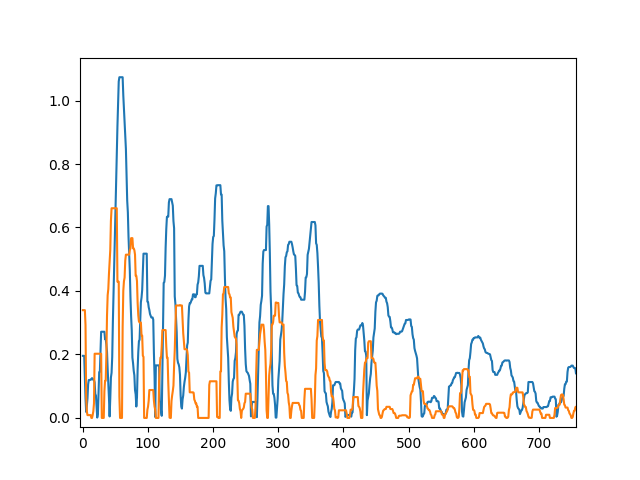

In [33]:
plt.figure()
plt.plot(abs_grad[:,100,100])
plt.plot(abs(sacc[:,100,100])*10)


In [10]:
dg = np.where((g_hi - g_lo) > 0, g_hi - g_lo, 1.0)
norm = np.clip((abs_grad - g_lo) / dg, 0.0, 1.0)

raw = w_max - norm * (w_max - w_min)
windows = np.round(raw).astype(int)
windows += (1 - windows % 2)
windows = np.clip(windows, _make_odd(w_min), _make_odd(w_max))

In [13]:
windows[:,100,100]

array([33, 33, 33, ..., 47, 47, 45])

In [16]:
b = data[:,100,100]
bs = medfilt(b,11)

<IPython.core.display.Javascript object>


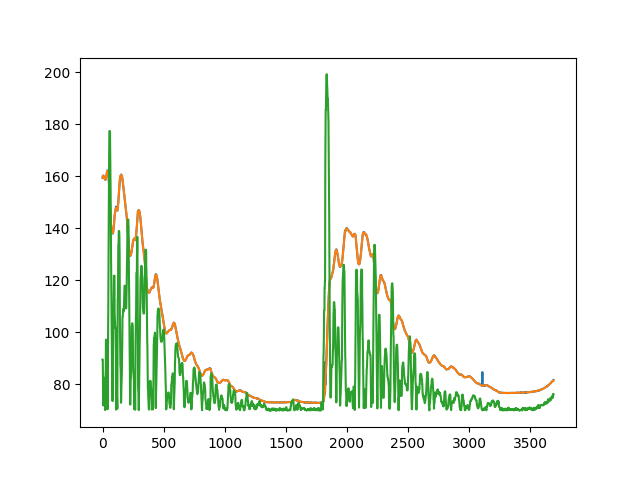

In [24]:
plt.figure()
plt.plot(b)
plt.plot(bs)
plt.plot(abs_grad[:,100,100]*100+70)

<IPython.core.display.Javascript object>


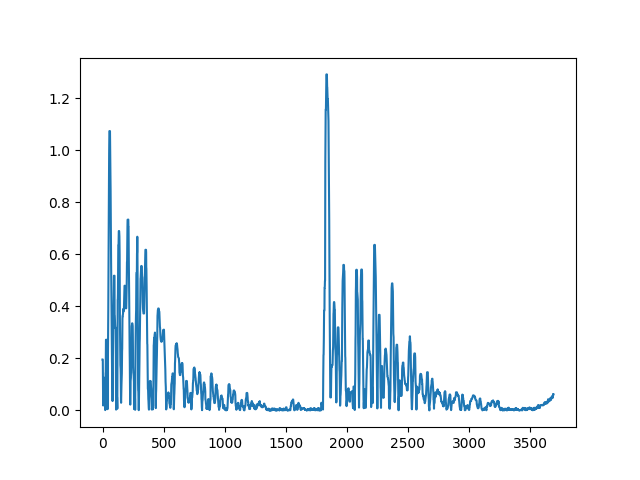

In [9]:
plt.figure()
plt.plot(abs_grad[:,100,100])

<IPython.core.display.Javascript object>


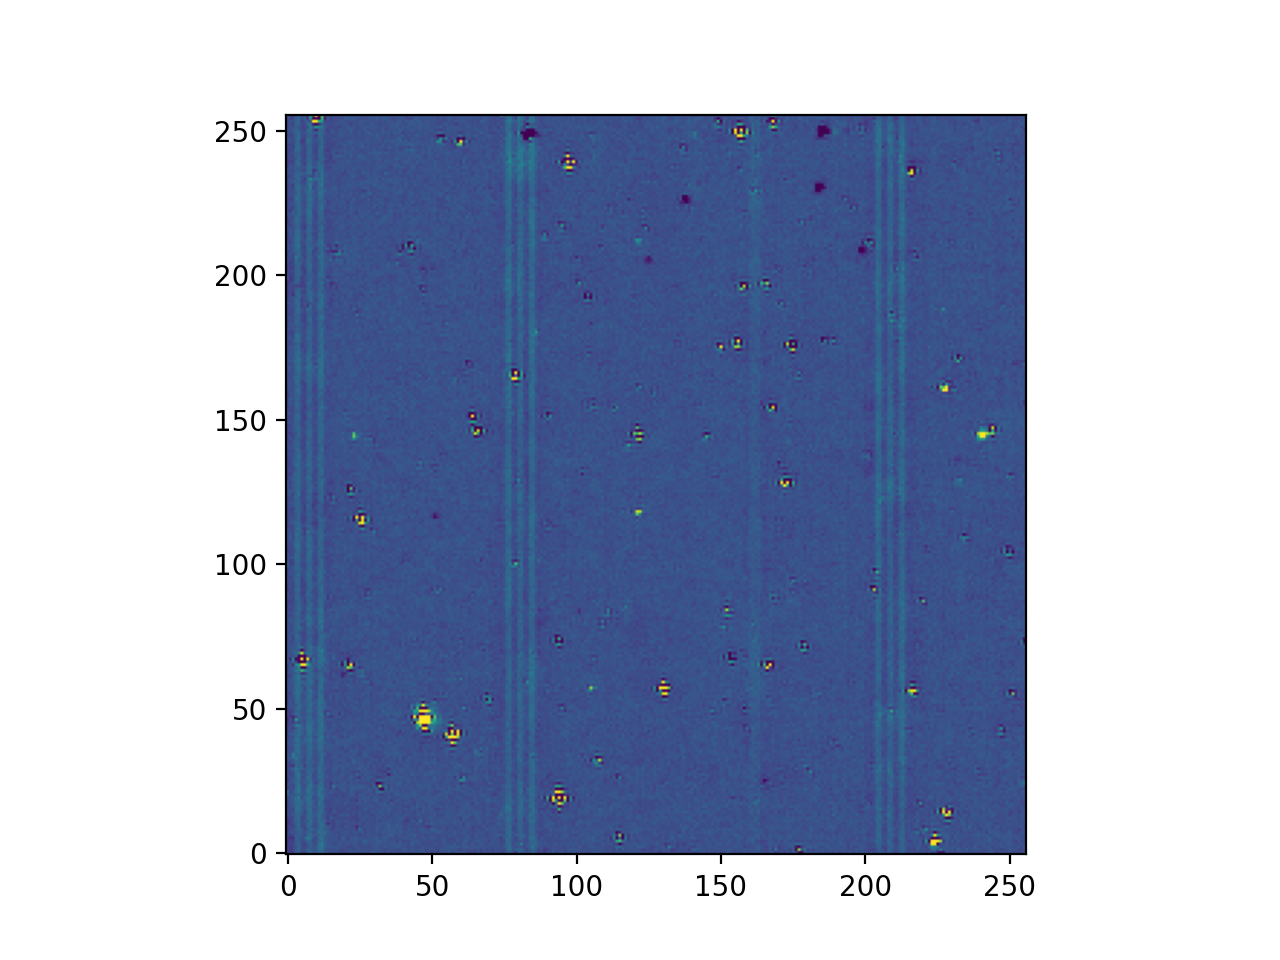

In [18]:
plt.figure()
plt.imshow(tess.flux[10]-(tess.ref-tess.bkg[tess.ref_ind]),vmin=-10,vmax=30,origin='lower')

<IPython.core.display.Javascript object>


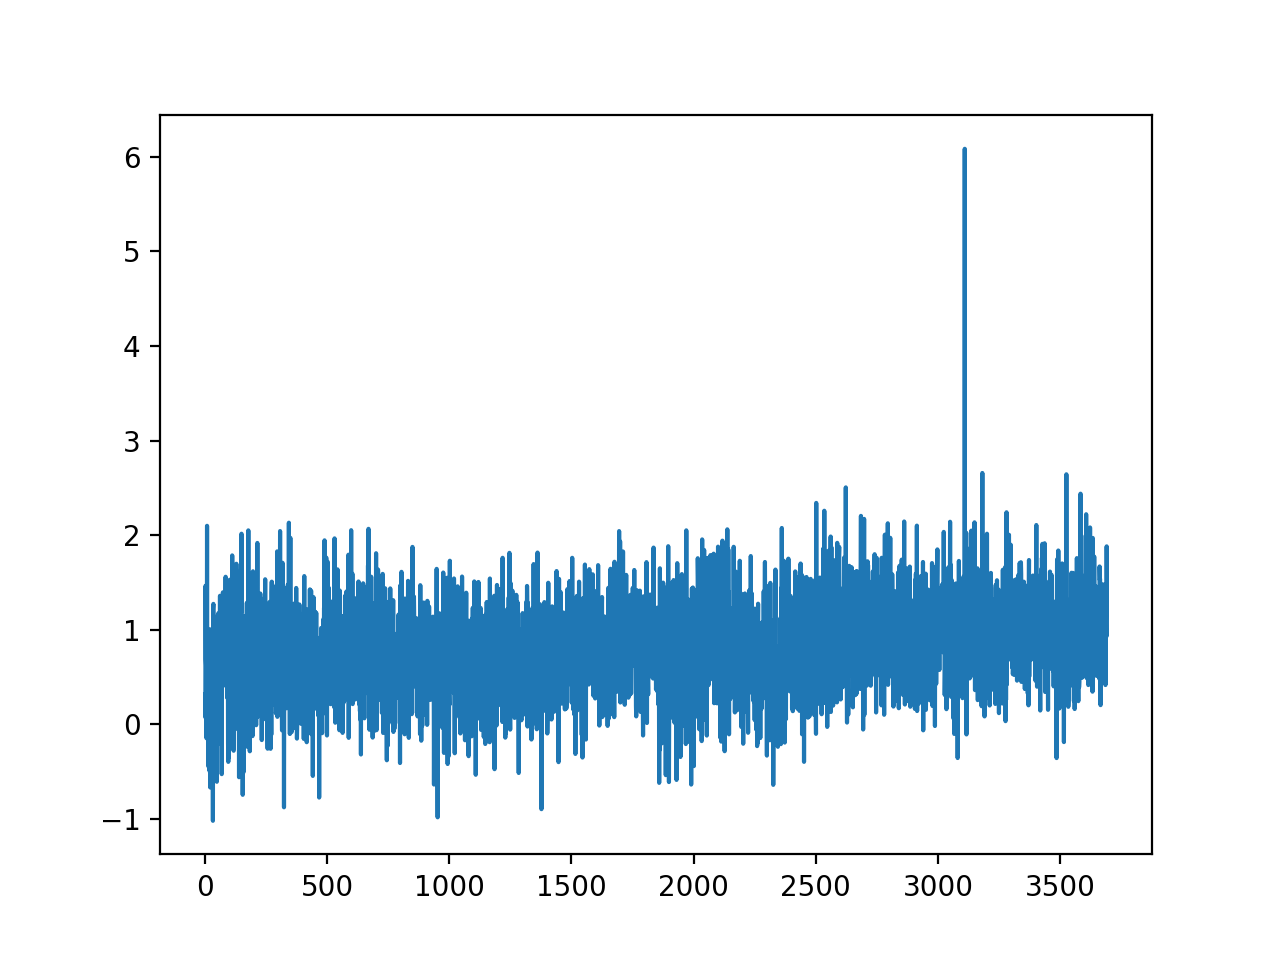

In [9]:
plt.figure()
plt.plot(tess.flux[:,143-10,174-10])

In [ ]:

# Adaptive median: loop over unique window sizes
result = np.empty((T, X, Y))
for w in np.unique(windows):
    smoothed_w = median_filter(data_filled, size=(w, 1, 1), mode='reflect')
    result[windows == w] = smoothed_w[windows == w]

result[nan_mask] = np.nan

In [5]:
sbkg,ws,grad = adaptive_medfilt_3d(tess.bkg)

KeyboardInterrupt: 

In [8]:
tess.flux.shape

(3693, 256, 256)

In [9]:
av_bkg.shape

(3693,)

In [6]:
av_bkg = np.nanmedian(tess.flux,axis=(1,2))

In [7]:
from scipy.signal import medfilt

In [32]:
g = (np.gradient(tess.bkg[:,100,100]))
gs = medfilt(g,kernel_size=7)
b = tess.bkg[:,100,100]
bs = medfilt(tess.bkg,kernel_size=(11,3,3))

In [34]:
plt.figure()
plt.plot(b)
plt.plot(bs[:,100,100])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


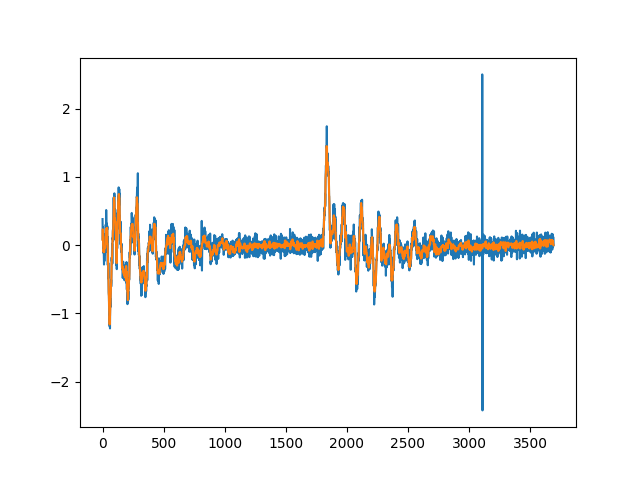

In [18]:
plt.figure()
plt.plot(g)
plt.plot(gs)

In [23]:
import sep
import pandas as pd

In [183]:
data = tess.ref.byteswap().newbyteorder()
# data = tess.flux[100].byteswap().newbyteorder()
#edata = tess.eflux[tess.ref_ind].byteswap().newbyteorder()
bkg = sep.Background(data)
objects = sep.extract(data- np.nanmedian(data), 50,)

In [179]:
objects = pd.DataFrame(objects)
w = objects['a'].values
h = objects['b'].values
ratio = np.round(abs(w/h - 1),1)
objects = objects.iloc[ratio < 0.5]

In [184]:
np.save('testref.npy',data)

In [180]:
objects.to_csv('test100.csv',index=False)

In [181]:
tess.ref_ind

1438

In [159]:
objects.keys()

Index(['thresh', 'npix', 'tnpix', 'xmin', 'xmax', 'ymin', 'ymax', 'x', 'y',
       'x2', 'y2', 'xy', 'errx2', 'erry2', 'errxy', 'a', 'b', 'theta', 'cxx',
       'cyy', 'cxy', 'cflux', 'flux', 'cpeak', 'peak', 'xcpeak', 'ycpeak',
       'xpeak', 'ypeak', 'flag'],
      dtype='object')

In [155]:
ind = ratio < 0.5

In [161]:
objects[['x','x2']]

,x,x2
0,168.791436,0.683582
1,176.890029,0.966993
2,80.922955,0.564643
3,131.922478,0.502342
4,6.260260,0.429477
...,...,...
249,237.956958,0.359582
250,9.909438,1.230163
251,74.584634,1.445189
252,168.005684,1.265719


<IPython.core.display.Javascript object>


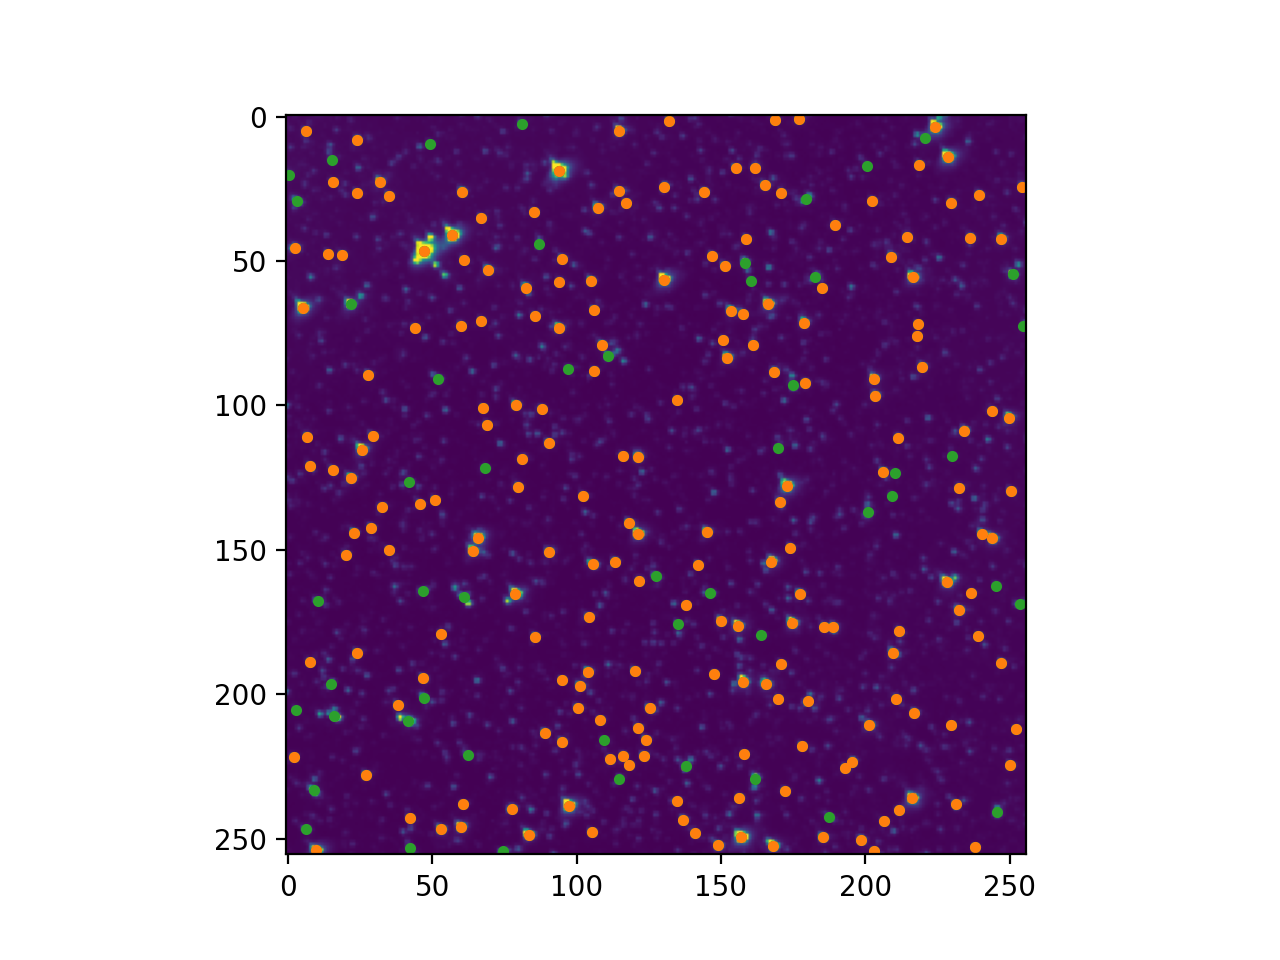

In [157]:
plt.figure()
plt.imshow(tess.ref,vmax=1200)
plt.plot(objects['x'],objects['y'],'C2.')
plt.plot(objects['x'][ind],objects['y'][ind],'C1.')

In [88]:
def bkg_temporal_smooth(self,window_size=None):
    if window_size is None:
        window_size = self._bkg_temporal_window # still need to decide what this is 
        
    grad = np.gradient(self.bkg[:,25,25],lc[0])
    time = self.mjd
    m,med,std = sigma_clipped_stats(abs(grad))
    ind = abs(grad) < (med + 5*std)
    ind_where = np.where(ind)[0]

    breaks = np.where(np.diff(time[ind]) > 1)[0]+1
    breaks = np.insert(breaks, 0, 0)
    breaks = np.append(breaks, len(time[ind]))

    new_bkg = self.bkg.copy()  # shape (T, X, Y)

    for i in range(len(breaks) - 1):
        seg_idx = ind_where[breaks[i]:breaks[i+1]]
        seg = new_bkg[seg_idx]                                      # (n_seg, X, Y)
        sav = savgol_filter(seg, 501, 1, axis=0)                     # (n_seg, X, Y)

        # per-pixel residual threshold
        resid     = np.abs(seg - sav)                               # (n_seg, X, Y)
        threshold = np.median(resid, axis=0) + 5 * np.std(resid, axis=0)  # (X, Y)

        exceeds = resid > threshold[np.newaxis]                     # (n_seg, X, Y)

        # leading bad run: cumprod stays 1 only while all preceding values were True
        start_clip = np.cumprod(exceeds,axis=0).sum(axis=0)  # (X, Y)
        end_clip   = len(seg_idx) - np.cumprod(exceeds[::-1], axis=0).sum(axis=0)

        # use sav only within [start_clip, end_clip), raw outside
        t = np.arange(len(seg_idx))[:, np.newaxis, np.newaxis]      # (n_seg, 1, 1)
        use_sav = (t >= start_clip) & (t < end_clip)

        new_bkg[seg_idx] = np.where(use_sav, sav, seg)

#     flux = deepcopy(self.flux)
#     flux += self.bkg - new_bkg
    med = sigma_clipped_stats(flux,axis=(1,2))[1]
    flux = flux - med[:,np.newaxis,np.newaxis]
    new_bkg += med[:,np.newaxis,np.newaxis]
    self.bkg = new_bkg
    self.flux = flux


In [214]:
ind = abs(grad) < (med + 5*std)
ind_where = np.where(ind)[0]

breaks = np.where(np.diff(time[ind]) > 1)[0]+1
breaks = np.insert(breaks, 0, 0)
breaks = np.append(breaks, len(time[ind]))

new_bkg = tess.bkg.copy()  # shape (T, X, Y)

for i in range(len(breaks) - 1):
    seg_idx = ind_where[breaks[i]:breaks[i+1]]
    seg = new_bkg[seg_idx]                                      # (n_seg, X, Y)
    sav = savgol_filter(seg, 501, 1, axis=0)                     # (n_seg, X, Y)

    # per-pixel residual threshold
    resid     = np.abs(seg - sav)                               # (n_seg, X, Y)
    threshold = np.median(resid, axis=0) + 5 * np.std(resid, axis=0)  # (X, Y)

    exceeds = resid > threshold[np.newaxis]                     # (n_seg, X, Y)

    # leading bad run: cumprod stays 1 only while all preceding values were True
    start_clip = np.cumprod(exceeds,        axis=0).sum(axis=0)  # (X, Y)
    end_clip   = len(seg_idx) - np.cumprod(exceeds[::-1], axis=0).sum(axis=0)

    # use sav only within [start_clip, end_clip), raw outside
    t = np.arange(len(seg_idx))[:, np.newaxis, np.newaxis]      # (n_seg, 1, 1)
    use_sav = (t >= start_clip) & (t < end_clip)

    new_bkg[seg_idx] = np.where(use_sav, sav, seg)

flux = deepcopy(tess.flux)
flux += tess.bkg - new_bkg
med = sigma_clipped_stats(flux,axis=(1,2))[1]
flux = flux - med[:,np.newaxis,np.newaxis]
new_bkg += med[:,np.newaxis,np.newaxis]


<IPython.core.display.Javascript object>


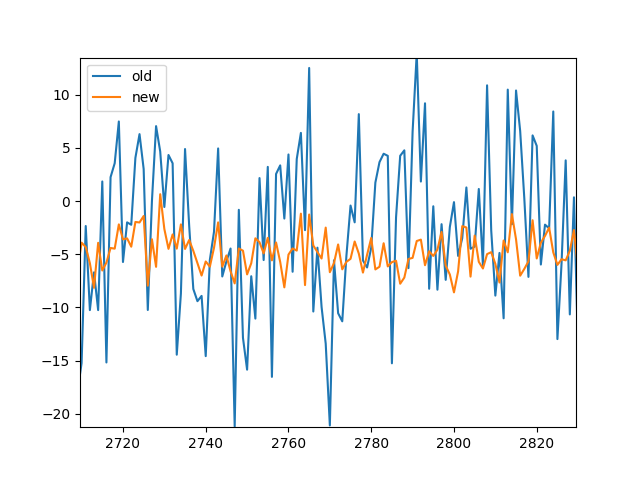

In [218]:
plt.figure()
plt.plot(np.nansum(tess.flux[:,24:27,24:27],axis=(1,2)),label='old')
plt.plot(np.nansum(flux[:,24:27,24:27],axis=(1,2)),label='new')
#plt.plot(np.nansum(aflux[:,24:27,24:27],axis=(1,2)),label='new')
plt.legend()

In [190]:
np.save('flux_test.npy',tess.flux)

In [219]:
lc1 = np.nansum(tess.flux[:,24:27,24:27],axis=(1,2))
lc2 = np.nansum(flux[:,24:27,24:27],axis=(1,2))

In [224]:
sigma_clipped_stats(lc1)[2] * 3

27.354153455917178

In [225]:
sigma_clipped_stats(lc2)[2] *3

15.741954697000537

<IPython.core.display.Javascript object>


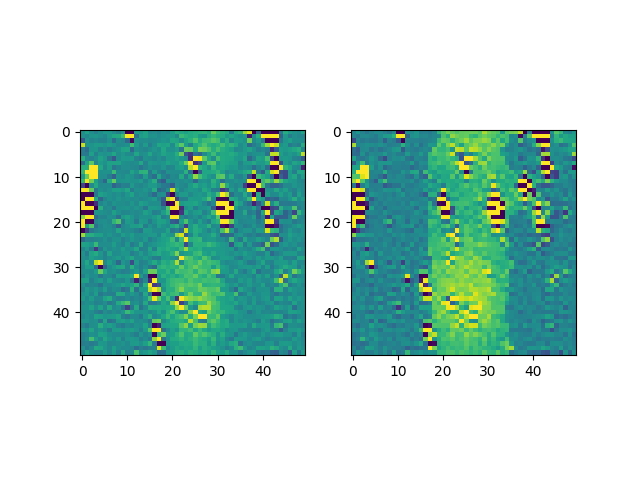

In [222]:
j = 1835#2855
plt.figure()
plt.subplot(121)
plt.imshow(tess.flux[j],vmin=-10,vmax=10)

plt.subplot(122)
plt.imshow(flux[j],vmin=-10,vmax=10)

In [159]:
a[1]

array([ 0.13595049,  0.21746506,  0.10541646, ..., -0.1851571 ,
        0.30301034,  0.19434366])

In [147]:
sigma_clipped_stats(tess.flux[j] + tess.bkg[j] - new_bkg[j])

(0.28194623356385085, 0.2497329419029134, 1.2707684836536026)

<IPython.core.display.Javascript object>


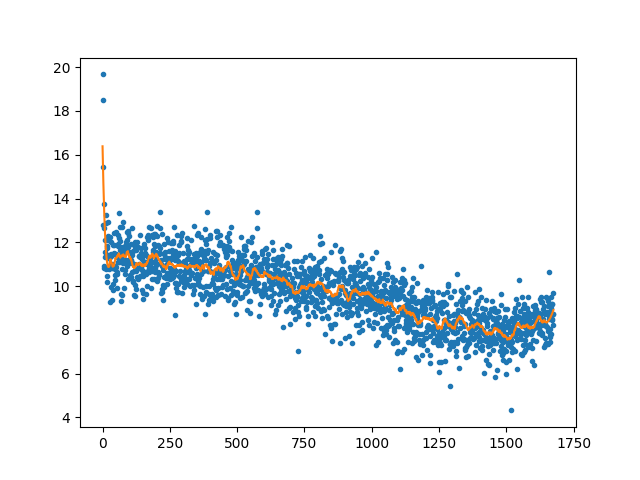

<IPython.core.display.Javascript object>


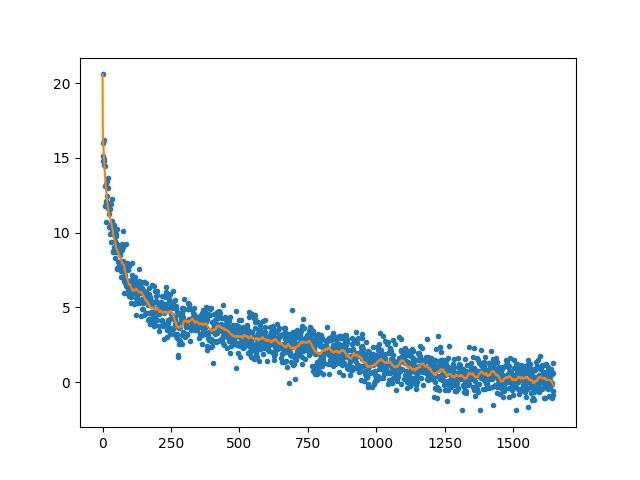

In [163]:
ind = abs(grad) < (med + 5*std)
ind_where = np.where(ind)[0]

breaks = np.where(np.diff(time[ind]) > 1)[0]+1
breaks = np.insert(breaks, 0, 0)
breaks = np.append(breaks, len(time[ind]))

new_bkg = deepcopy(tess.bkg[:,25,25])

for i in range(len(breaks) - 1):
    seg_idx = ind_where[breaks[i]:breaks[i+1]]
    seg     = new_bkg[seg_idx]
    sav     = savgol_filter(seg, 51, 3)

    # find poorly-fit edge points and revert to original
    resid     = np.abs(seg - sav)
    threshold = np.median(resid) + 5 * np.std(resid)

    # clip start: walk inward until residual is acceptable
    start_clip = 0
    for j in range(len(sav)):
        if resid[j] > threshold:
            start_clip = j + 1
        else:
            break

    # clip end: walk inward from the right
    end_clip = len(sav)
    for j in range(len(sav) - 1, -1, -1):
        if resid[j] > threshold:
            end_clip = j
        else:
            break

    sav[:start_clip] = seg[:start_clip]
    sav[end_clip:]   = seg[end_clip:]

#     plt.figure()
#     plt.plot(seg, '.')
#     plt.plot(sav)
    new_bkg[seg_idx] = sav
    
flux = deepcopy(tess.flux)
flux += tess.bkg - new_bkg
med = sigma_clipped_stats(flux,axis=(1,2))[1]
flux = flux - med
    
    
# plt.figure()
# plt.plot(tess.bkg[ind,25,25],'.')
# plt.plot(new_bkg[ind])

# plt.figure()
# plt.plot(tess.bkg[:,25,25]-new_bkg,'.')



In [161]:
new_bkg.shape

(3471,)

<IPython.core.display.Javascript object>


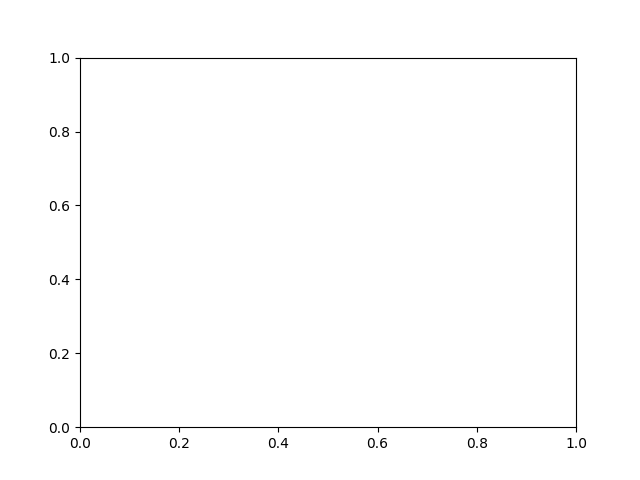

ValueError: x and y can be no greater than 2D, but have shapes (3471,) and (3471, 50, 50)

In [167]:
plt.figure()
plt.plot(new_bkg,label='bkg')
plt.plot(tess.flux[:,25,25],'.',label='lc')
plt.plot(tess.flux[:,25,25] + tess.bkg[:,25,25] - new_bkg,'.',label='lc')
plt.legend()
plt.ylim(-4,20)

In [126]:
sigma_clipped_stats(tess.flux[:,25,25])

(0.1992238794252621, 0.14485954705463833, 1.2108414313258078)

In [125]:
sigma_clipped_stats(tess.flux[:,25,25] + tess.bkg[:,25,25] - new_bkg)

(0.18983479459023306, 0.13764954448826572, 0.9358091876427621)

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def adaptive_gaussian_smooth(time, bkg, sigma_min_hrs=0.5, sigma_max_hrs=6,
                              n_levels=15, gap_threshold_hrs=1.0,
                              raw_grad_threshold=0.3, spike_nsigma=5):
    '''
    Adaptive Gaussian smoothing in physical time units, respecting data gaps.

    Points are left as raw data if they have a high local gradient OR are
    significantly elevated above the local baseline (catches full spike decay).

    Parameters
    ----------
    time               : 1D array of times (days)
    bkg                : 1D array of background values
    sigma_min_hrs      : minimum smoothing width in hours (near rapid changes)
    sigma_max_hrs      : maximum smoothing width in hours (steady regions)
    n_levels           : number of pre-computed sigma levels
    gap_threshold_hrs  : gaps larger than this split data into independent segments
    raw_grad_threshold : gradient fraction [0-1] above which points are left raw
    spike_nsigma       : points more than this many sigma above local baseline
                         are also left raw
    '''
    dt_hrs    = np.median(np.diff(time)) * 24
    sigma_min = sigma_min_hrs / dt_hrs
    sigma_max = sigma_max_hrs / dt_hrs

    gaps       = np.diff(time) * 24
    seg_breaks = np.where(gaps > gap_threshold_hrs)[0] + 1
    seg_starts = np.concatenate([[0], seg_breaks])
    seg_ends   = np.concatenate([seg_breaks, [len(bkg)]])

    result = bkg.copy()

    for s, e in zip(seg_starts, seg_ends):
        seg    = bkg[s:e]
        sigmas = np.geomspace(sigma_min, sigma_max, n_levels)

        # Robust baseline and noise estimate from the lower 60th percentile
        lo      = seg <= np.percentile(seg, 60)
        baseline = np.median(seg[lo])
        noise    = np.median(np.abs(seg[lo] - baseline))
        noise    = max(noise, 1e-6)

        # Gradient-based raw mask
        grad      = np.abs(np.gradient(seg))
        p_hi      = np.percentile(grad, 99)
        grad_norm = np.clip(grad / (p_hi + 1e-10), 0, 1)

        # Combined raw mask: high gradient OR elevated above baseline
        raw_mask    = (grad_norm >= raw_grad_threshold) | (seg > baseline + spike_nsigma * noise)
        smooth_mask = ~raw_mask

        # Sigma index: high gradient -> sigma_min, flat -> sigma_max
        sigma_idx = (1.0 - grad_norm ** 2) * (n_levels - 1)
        sigma_idx = gaussian_filter1d(sigma_idx, sigma=max(1, 1.0 / dt_hrs))
        sigma_idx = np.clip(sigma_idx, 0, n_levels - 1)

        # Pre-compute smoothed versions at each sigma level
        smoothed = np.array([gaussian_filter1d(seg, sigma=sig, mode='nearest')
                             for sig in sigmas])

        # Interpolate between adjacent levels
        idx_lo  = np.clip(sigma_idx.astype(int), 0, n_levels - 2)
        idx_hi  = idx_lo + 1
        frac    = sigma_idx - idx_lo
        val_lo  = np.take_along_axis(smoothed, idx_lo[np.newaxis], axis=0)[0]
        val_hi  = np.take_along_axis(smoothed, idx_hi[np.newaxis], axis=0)[0]
        blended = (1.0 - frac) * val_lo + frac * val_hi

        seg_result = seg.copy()
        seg_result[smooth_mask] = blended[smooth_mask]
        result[s:e] = seg_result

    return result

In [20]:
lc = np.array([tess.tpf.time.mjd,tess.bkg[:,25,25]])

In [22]:
lc.shape

(2, 3471)

In [23]:
np.save('test_bkg.npy',lc)

In [17]:
!pwd

/Users/rri38/Documents/work/code/tess/tessreduce/development


<IPython.core.display.Javascript object>


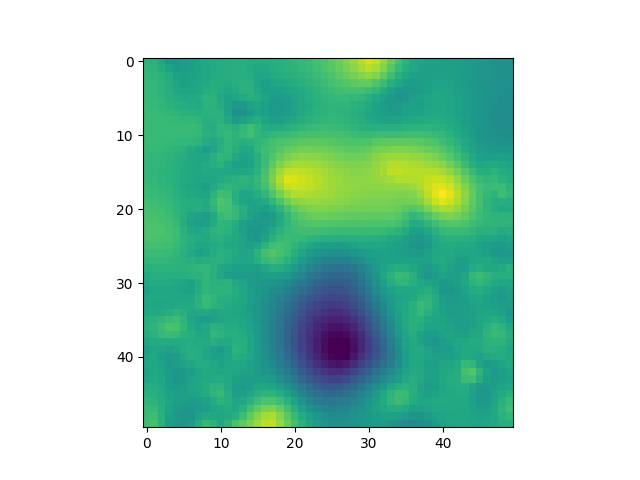

In [11]:
plt.figure()
plt.imshow(tess.bkg[1000])